In [1]:
import pandas as pd
import numpy as np
import os
import cv2

from PIL import Image
from keras.preprocessing.image import load_img

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

import tensorflow as tf

from keras.models import Sequential, Model
from keras.layers import (
    Dense,
    Conv2D,
    Dropout,
    Flatten,
    MaxPooling2D,
    Input
)

from tensorflow.keras.utils import plot_model
from pathlib import Path
from sklearn.model_selection import train_test_split
from tensorflow.keras.initializers import (
    RandomUniform,
    GlorotUniform,
    Constant,
    Identity
)

from tensorflow.keras.layers import (
    Add,
    BatchNormalization,
    GlobalMaxPooling2D
)

from tensorflow.keras import datasets, layers, models
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

In [2]:
BASE_DIRS =[r'/kaggle/input/datasets/jangedoo/utkface-new/UTKFace']

In [3]:
img_paths=[]
age_labels=[]
gender_paths=[]

In [4]:
from tqdm import tqdm
for BASE_DIR in BASE_DIRS:
    for filename in tqdm(os.listdir(BASE_DIR)):
        temp = filename.split('_')
        if temp[0].isdigit():
            age = int(temp[0])
            gender = int(temp[1])
            image_path = os.path.join(BASE_DIR, filename)
            
            img_paths.append(image_path) 
            
            age_labels.append(age)
            gender_paths.append(gender)

100%|██████████| 23708/23708 [00:00<00:00, 494958.06it/s]


In [5]:
df = pd.DataFrame()
df['image'], df['age'], df['gender'] = img_paths, age_labels, gender_paths
df.head()

,image,age,gender
0,/kaggle/input/datasets/jangedoo/utkface-new/UT...,26,0
1,/kaggle/input/datasets/jangedoo/utkface-new/UT...,22,1
2,/kaggle/input/datasets/jangedoo/utkface-new/UT...,21,1
3,/kaggle/input/datasets/jangedoo/utkface-new/UT...,28,0
4,/kaggle/input/datasets/jangedoo/utkface-new/UT...,17,1


In [6]:
print(df)
print(df.shape)

                                                   image  age  gender
0      /kaggle/input/datasets/jangedoo/utkface-new/UT...   26       0
1      /kaggle/input/datasets/jangedoo/utkface-new/UT...   22       1
2      /kaggle/input/datasets/jangedoo/utkface-new/UT...   21       1
3      /kaggle/input/datasets/jangedoo/utkface-new/UT...   28       0
4      /kaggle/input/datasets/jangedoo/utkface-new/UT...   17       1
...                                                  ...  ...     ...
23703  /kaggle/input/datasets/jangedoo/utkface-new/UT...   41       0
23704  /kaggle/input/datasets/jangedoo/utkface-new/UT...   42       0
23705  /kaggle/input/datasets/jangedoo/utkface-new/UT...    2       0
23706  /kaggle/input/datasets/jangedoo/utkface-new/UT...   65       1
23707  /kaggle/input/datasets/jangedoo/utkface-new/UT...   66       0

[23708 rows x 3 columns]
(23708, 3)


In [7]:
gender_dict={0:'male',1:'female'}

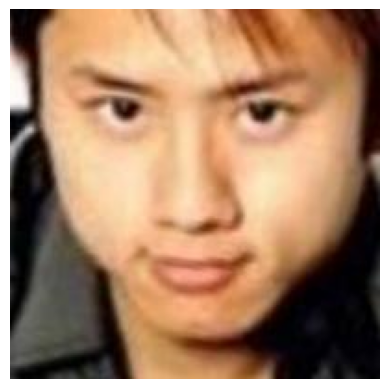

In [8]:
img=Image.open(df['image'][0])
plt.axis('off')
plt.imshow(img)
plt.show()

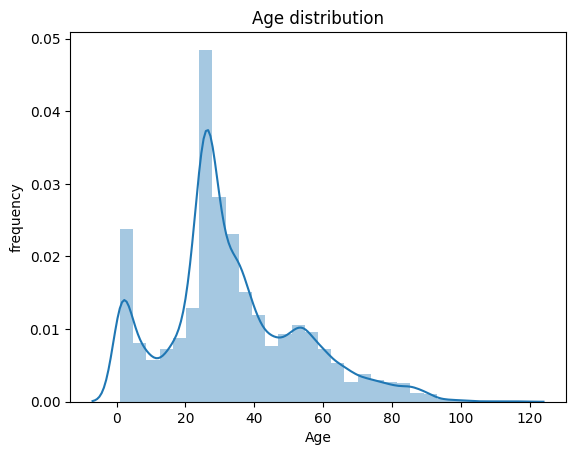

In [9]:
sns.distplot(df['age'],bins=30,kde=True)
plt.title('Age distribution')
plt.xlabel('Age')
plt.ylabel('frequency')
plt.show()

In [10]:
def feature_extraction(img_paths):
    features = []
    for path in tqdm(img_paths):
        img=Image.open(path).convert('L')
        img=img.resize((128,128),Image.BILINEAR)
        img=np.array(img)
        features.append(img)
    features=np.array(features)
    features=features.reshape(len(features),128,128,1)
    return features
    

In [11]:
x=feature_extraction(df['image'])
x.shape


100%|██████████| 23708/23708 [01:33<00:00, 253.40it/s]


(23708, 128, 128, 1)

In [12]:
print(x)

[[[[ 11]
   [  7]
   [  7]
   ...
   [ 27]
   [ 41]
   [ 48]]

  [[ 13]
   [  5]
   [  4]
   ...
   [ 20]
   [ 33]
   [ 44]]

  [[ 18]
   [  5]
   [  2]
   ...
   [ 15]
   [ 28]
   [ 42]]

  ...

  [[ 45]
   [ 36]
   [ 25]
   ...
   [  4]
   [  4]
   [  5]]

  [[ 40]
   [ 30]
   [ 17]
   ...
   [  2]
   [  3]
   [  6]]

  [[ 47]
   [ 35]
   [ 21]
   ...
   [  0]
   [  4]
   [  8]]]


 [[[  3]
   [  3]
   [  3]
   ...
   [ 20]
   [ 28]
   [ 35]]

  [[  4]
   [  4]
   [  4]
   ...
   [ 25]
   [ 34]
   [ 41]]

  [[  4]
   [  4]
   [  4]
   ...
   [ 30]
   [ 38]
   [ 45]]

  ...

  [[ 88]
   [ 89]
   [ 89]
   ...
   [ 73]
   [ 73]
   [ 72]]

  [[ 97]
   [ 97]
   [ 97]
   ...
   [ 74]
   [ 73]
   [ 72]]

  [[106]
   [106]
   [105]
   ...
   [ 76]
   [ 75]
   [ 74]]]


 [[[ 41]
   [ 38]
   [ 35]
   ...
   [110]
   [141]
   [171]]

  [[ 38]
   [ 36]
   [ 35]
   ...
   [102]
   [133]
   [164]]

  [[ 37]
   [ 35]
   [ 34]
   ...
   [ 91]
   [123]
   [155]]

  ...

  [[  9]
   [ 12]
   [ 16]
   

In [13]:
x=x/255.0

In [14]:
x.dtype

dtype('float64')

In [15]:
df['age']

0        26
1        22
2        21
3        28
4        17
         ..
23703    41
23704    42
23705     2
23706    65
23707    66
Name: age, Length: 23708, dtype: int64

In [16]:
y_age=np.array(df['age'])/100.0
y_age

array([0.26, 0.22, 0.21, ..., 0.02, 0.65, 0.66])

In [17]:
df['gender']

0        0
1        1
2        1
3        0
4        1
        ..
23703    0
23704    0
23705    0
23706    1
23707    0
Name: gender, Length: 23708, dtype: int64

In [18]:
y_gender=np.array(df['gender'])
y_gender

array([0, 1, 1, ..., 0, 1, 0])

In [19]:
print(y_age.shape,y_gender.shape)

(23708,) (23708,)


In [20]:
from tensorflow.keras.layers import (
    Input, Conv2D, BatchNormalization, Activation, MaxPooling2D, 
    GlobalAveragePooling2D, Dense, Dropout, RandomFlip, 
    RandomRotation, RandomZoom
)
from tensorflow.keras.models import Model

input_shape = (128, 128, 1)
inputs = Input(input_shape)

# Data Augmentation Block (Applied directly to the input)
x = RandomFlip("horizontal")(inputs)
x = RandomRotation(0.05)(x)  
x = RandomZoom(0.1)(x)       

# Block 1
cov1 = Conv2D(32, kernel_size=(3, 3), padding='same')(x)
bn1 = BatchNormalization()(cov1)
act1 = Activation('relu')(bn1)
max1 = MaxPooling2D(pool_size=(2, 2))(act1)
drop_c1 = Dropout(0.1)(max1) 

# Block 2
cov2 = Conv2D(64, kernel_size=(3, 3), padding='same')(drop_c1)
bn2 = BatchNormalization()(cov2)
act2 = Activation('relu')(bn2)
max2 = MaxPooling2D(pool_size=(2, 2))(act2)
drop_c2 = Dropout(0.15)(max2)

# Block 3
cov3 = Conv2D(128, kernel_size=(3, 3), padding='same')(drop_c2)
bn3 = BatchNormalization()(cov3)
act3 = Activation('relu')(bn3)
max3 = MaxPooling2D(pool_size=(2, 2))(act3)
drop_c3 = Dropout(0.2)(max3)

# Block 4
cov4 = Conv2D(256, kernel_size=(3, 3), padding='same')(drop_c3)
bn4 = BatchNormalization()(cov4)
act4 = Activation('relu')(bn4)
max4 = MaxPooling2D(pool_size=(2, 2))(act4)
drop_c4 = Dropout(0.25)(max4)

gap = GlobalAveragePooling2D()(drop_c4)

# Task-Specific Head 1: Gender Classification
dense1 = Dense(256, activation='relu')(gap)
drop1 = Dropout(0.4)(dense1)
output1 = Dense(1, activation='sigmoid', name='gender_out')(drop1)

# Task-Specific Head 2: Age Regression
dense2 = Dense(256, activation='relu')(gap)
drop2 = Dropout(0.4)(dense2)
output2 = Dense(1, activation='linear', name='age_out')(drop2)

# Construct Model
model1 = Model(inputs=inputs, outputs=[output1, output2])
model1.summary()

I0000 00:00:1791436572.620912      57 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1791436572.624433      57 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_flip         │ (None, 128, 128,  │          0 │ input_layer[0][0] │
│ (RandomFlip)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_rotation     │ (None, 128, 128,  │          0 │ random_flip[0][0] │
│ (RandomRotation)    │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_zoom         │ (None, 128, 128,  │          0 │ random_rotation[… │
│ (RandomZoom)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │        320 │ random_zoom[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128, 128,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ activation[0][0]  │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64, 64,    │          0 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 64, 64,    │     18,496 │ dropout[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 32, 32,    │          0 │ max_pooling2d_1[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 32, 32,    │     73,856 │ dropout_1[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        512 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 32, 32,    │          0 │ batch_normalizat

 Total params: 521,858 (1.99 MB)

 Trainable params: 520,898 (1.99 MB)

 Non-trainable params: 960 (3.75 KB)

In [25]:
import numpy as np

# Re-extract and normalize x from cell 11 to ensure it's a pure NumPy array (not a KerasTensor)
x = feature_extraction(df['image'])
x = x / 255.0

# Ensure y arrays are clean 1D numpy arrays
y_gender_arr = np.array(df['gender'].values)
y_age_arr = np.array(df['age'].values) / 100.0

# Combine into a 2D numpy array for splitting
y_combined = np.column_stack((y_gender_arr, y_age_arr))

# Split the pure numpy arrays
X_train, X_temp, y_combined_train, y_combined_temp = train_test_split(
    x, y_combined, test_size=0.2, random_state=42
)
x_test, x_val, y_combined_test, y_combined_val = train_test_split(
    X_temp, y_combined_temp, test_size=0.5, random_state=42
)

print("Shapes verified:", X_train.shape, y_combined_train.shape)

100%|██████████| 23708/23708 [00:31<00:00, 762.96it/s]


Shapes verified: (18966, 128, 128, 1) (18966, 2)


In [26]:
y_train_gender,y_train_age=y_combined_train[:,0],y_combined_train[:,1]
y_train_gender

array([0., 1., 0., ..., 0., 0., 0.])

In [27]:
y_train_age

array([0.23, 0.04, 0.5 , ..., 0.52, 0.3 , 0.01])

In [28]:
y_test_gender,y_test_age=y_combined_test[:,0],y_combined_test[:,1]
y_val_gender,y_val_age=y_combined_val[:,0],y_combined_val[:,1]

In [29]:
from keras.callbacks import LearningRateScheduler

# Changed decay base from 0.9 to 0.95 for a smoother descent
annealer = LearningRateScheduler(lambda x: 1e-3 * 0.95**x)

In [30]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

model_path = './model3.keras'

check_pointer = ModelCheckpoint(
    filepath=model_path,
    monitor='val_age_out_mae',
    verbose=1,
    save_best_only=True,
    mode='min'
)

early_stopping = EarlyStopping(
    monitor='val_age_out_mae', 
    patience=6, 
    restore_best_weights=True,
    mode='min',  # <--- Added this line
    verbose=1
)

In [31]:
model1.compile(
    loss={
        'gender_out': 'binary_crossentropy',
        'age_out': 'mae'  # Reverted to MAE for stable gradients
    },
    loss_weights={
        'gender_out': 1.0, 
        'age_out': 2.0    # Reduced from 5.0 to balance the dual-head updates
    },
    optimizer='adam',
    metrics={
        'gender_out': ['accuracy'],
        'age_out': ['mae']
    }
)

In [32]:
train_imgs=len(X_train)
test_imgs=len(x_test)
val_imgs=len(x_val)
total_images=len(img_paths)
print("total=",total_images)
print("train_imgs=",train_imgs)
print('test_imgs=',test_imgs)
print('val_imgs=',val_imgs)

total= 23708
train_imgs= 18966
test_imgs= 2371
val_imgs= 2371


In [33]:
import tensorflow as tf
tf.config.run_functions_eagerly(True)

In [35]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

reduce_lr = ReduceLROnPlateau(
    monitor='val_age_out_mae',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    mode='min',  # <--- Added this line
    verbose=1
)

history1 = model1.fit(
    x=X_train,
    y=[y_train_gender, y_train_age],
    batch_size=64,
    epochs=40,
    validation_data=(x_val, [y_val_gender, y_val_age]),
    callbacks=[reduce_lr, check_pointer, early_stopping]
)

Epoch 1/40
297/297 ━━━━━━━━━━━━━━━━━━━━ 0s 293ms/step - age_out_loss: 0.1328 - age_out_mae: 0.1328 - gender_out_accuracy: 0.6835 - gender_out_loss: 0.5910 - loss: 0.8567
Epoch 1: val_age_out_mae improved from None to 0.46936, saving model to ./model3.keras

Epoch 1: finished saving model to ./model3.keras
297/297 ━━━━━━━━━━━━━━━━━━━━ 90s 303ms/step - age_out_loss: 0.1301 - age_out_mae: 0.1301 - gender_out_accuracy: 0.6956 - gender_out_loss: 0.5784 - loss: 0.8386 - val_age_out_loss: 0.4694 - val_age_out_mae: 0.4694 - val_gender_out_accuracy: 0.5331 - val_gender_out_loss: 1.0418 - val_loss: 1.9805 - learning_rate: 0.0010
Epoch 2/40
297/297 ━━━━━━━━━━━━━━━━━━━━ 0s 295ms/step - age_out_loss: 0.1243 - age_out_mae: 0.1243 - gender_out_accuracy: 0.7244 - gender_out_loss: 0.5440 - loss: 0.7926
Epoch 2: val_age_out_mae improved from 0.46936 to 0.16814, saving model to ./model3.keras

Epoch 2: finished saving model to ./model3.keras
297/297 ━━━━━━━━━━━━━━━━━━━━ 90s 302ms/step - age_out_loss: 0.1

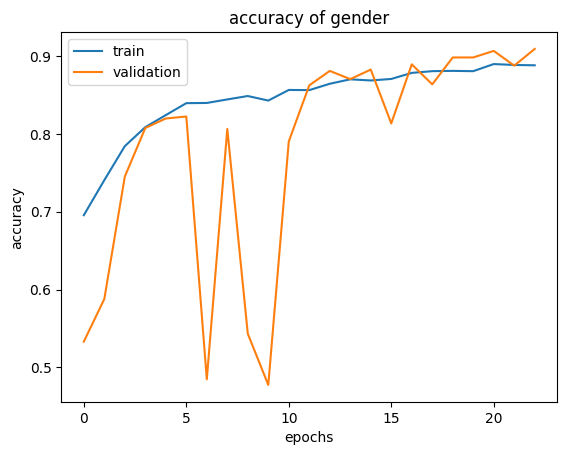

In [36]:
plt.plot(history1.history['gender_out_accuracy'])
plt.plot(history1.history['val_gender_out_accuracy'])
plt.xlabel('epochs')
plt.ylabel('accuracy')
plt.title('accuracy of gender')
plt.legend(['train','validation'],loc='upper left')
plt.show()

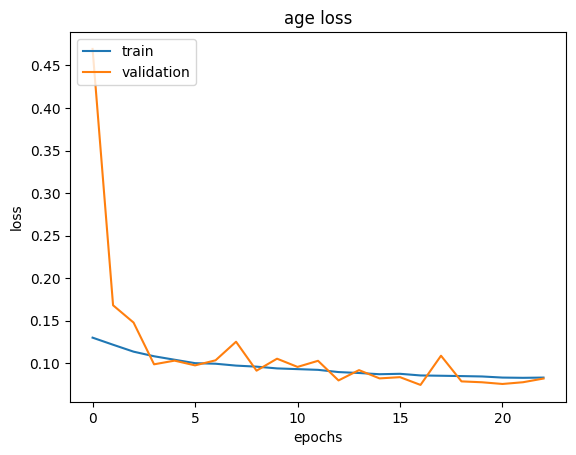

In [37]:
plt.plot(history1.history['age_out_mae'])
plt.plot(history1.history['val_age_out_mae'])
plt.xlabel('epochs')
plt.ylabel('loss')
plt.title('age loss')
plt.legend(['train','validation'],loc='upper left')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step


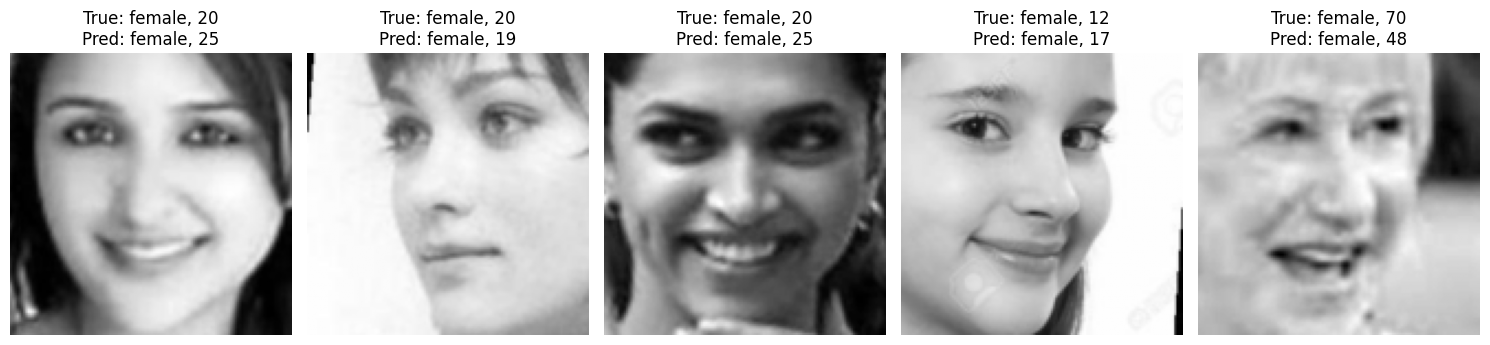

In [38]:
import matplotlib.pyplot as plt
import numpy as np

num_samples = 5
sample_images = x_test[:num_samples]
true_genders = y_test_gender[:num_samples]
true_ages = y_test_age[:num_samples]

predictions = model1.predict(sample_images)

# Extract gender probabilities and age regression values
# gender_out is the first output, age_out is the second output[cite: 1]
pred_genders = predictions[0] 
pred_ages = predictions[1]

# Plot the results side-by-side
fig, axes = plt.subplots(1, num_samples, figsize=(15, 5))
for i in range(num_samples):
    # Convert sigmoid probability to binary class (0 or 1) and map to dictionary[cite: 1]
    pred_gender_label = gender_dict[int(np.round(pred_genders[i][0]))]
    true_gender_label = gender_dict[int(true_genders[i])]
    
    # Multiply by 100 to reverse the age normalization applied during preprocessing[cite: 1]
    pred_age_val = int(pred_ages[i][0] * 100)
    true_age_val = int(true_ages[i] * 100)
    
    # Display the 128x128 grayscale image[cite: 1]
    axes[i].imshow(sample_images[i].reshape(128, 128), cmap='gray')
    axes[i].axis('off')
    axes[i].set_title(f"True: {true_gender_label}, {true_age_val}\nPred: {pred_gender_label}, {pred_age_val}")

plt.tight_layout()
plt.show()